# Reviewed ANOVA-GP Workflow for NylC PA6 Activity

This notebook is a stricter, reviewer-oriented update of
`03b_ANOVA_GP.ipynb`.

Main changes:

- amino-acid physicochemical vectors are imported from `peptides.py`;
- project paths are resolved relative to the repository;
- nested LOOCV is used as the primary validation;
- additive and epistatic ANOVA-GP models are compared under identical
  nested validation;
- uncertainty calibration is evaluated explicitly;
- errors are summarized by mutation order and mutation family;
- descriptor-set sensitivity is treated as exploratory.

Reporting rule:

- Primary result: nested LOOCV model comparison.
- Secondary result: descriptor and holdout sensitivity analyses.

## Descriptor-source decision

The original notebook hardcoded 8 amino-acid properties. This version
avoids that by using `peptides.py`, which exposes established descriptor
families such as Kidera factors, Atchley factors, VHSE scales, Z-scales
and PCP descriptors. For a single residue, `Peptide("A").kidera_factors()`
returns the vector for that residue because the package averages over
the supplied sequence.

Documentation consulted:

- `peptides.py`: https://peptides.readthedocs.io/en/latest/
- `Peptide` API: https://peptides.readthedocs.io/en/latest/api/peptide.html
- Biopython ProtParam: https://biopython.org/docs/latest/api/Bio.SeqUtils.ProtParam.html
- modlAMP descriptors: https://modlamp.org/modlamp.html

`peptides.py` is used as the primary source because it provides compact
residue-level QSAR descriptor families. Biopython and modlAMP are useful
alternatives for sequence-level descriptors, but are less direct for the
position-wise kernel used here.

In [1]:
pip install peptides

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dataclasses import dataclass
from itertools import product
from pathlib import Path
import math
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, wilcoxon
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "matrices" / "NylC_Puetz_raw_data.CSV").exists():
            return candidate
    if start.name == "Notebooks":
        return start.parent
    raise FileNotFoundError("Could not locate matrices/NylC_Puetz_raw_data.CSV")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "matrices" / "NylC_Puetz_raw_data.CSV"
OUTPUT_DIR = PROJECT_ROOT / "results" / "anova_gp_reviewed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)

Python: 3.9.21
Platform: Linux-5.14.0-570.58.1.el9_6.x86_64-x86_64-with-glibc2.34
Project root: /rwthfs/rz/cluster/home/dwp46550/ba_nylon
Data path: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/matrices/NylC_Puetz_raw_data.CSV
Output dir: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed


In [3]:
try:
    import peptides
    from peptides import Peptide
except ImportError as exc:
    raise ImportError(
        "This notebook uses peptides.py for amino-acid descriptor vectors. "
        "Install it in the active environment, for example: pip install peptides"
    ) from exc

print("peptides.py version:", getattr(peptides, "__version__", "unknown"))

peptides.py version: 0.5.0


## Load and aggregate experimental activity

The target is the mean PA6 activity across available experimental
replicates. The SEM is retained as observation-level uncertainty and
added to the GP covariance after target standardization.

In [4]:
df_raw = pd.read_csv(DATA_PATH, sep=";", decimal=",")

activity_rep_cols = [col for col in df_raw.columns if col.startswith("activity_pa6_")]
if not activity_rep_cols:
    raise ValueError("No activity replicate columns found.")

df = df_raw.copy()
df[activity_rep_cols] = df[activity_rep_cols].apply(pd.to_numeric, errors="coerce")
df["activity_n"] = df[activity_rep_cols].count(axis=1)
df["activity_pa6"] = df[activity_rep_cols].mean(axis=1, skipna=True)
df["activity_sd"] = df[activity_rep_cols].std(axis=1, skipna=True, ddof=1)
df["activity_sem"] = df["activity_sd"] / np.sqrt(df["activity_n"])

if df["activity_pa6"].isna().any():
    raise ValueError("At least one variant has no usable PA6 activity.")

fallback_sem = df.loc[df["activity_sem"].notna() & (df["activity_sem"] > 0), "activity_sem"].median()
if not np.isfinite(fallback_sem):
    fallback_sem = 0.0
df["activity_sem_for_gp"] = df["activity_sem"].fillna(fallback_sem)

summary_cols = [
    "variant_id", "mutations", "activity_n", "activity_pa6",
    "activity_sd", "activity_sem", "activity_sem_for_gp",
]
display(df[summary_cols].head(12))
print("n variants:", len(df))
print("activity range:", (df["activity_pa6"].min(), df["activity_pa6"].max()))
print("median SEM fallback:", fallback_sem)

,variant_id,mutations,activity_n,activity_pa6,activity_sd,activity_sem,activity_sem_for_gp
0,WT,NaN,3,77.666667,2.309401,1.333333,1.333333
1,D99G,D99G,3,144.000000,19.313208,11.150486,11.150486
2,D99V,D99V,3,147.666667,6.027714,3.480102,3.480102
3,D99R,D99R,2,194.000000,14.142136,10.000000,10.000000
4,F134W,F134W,2,217.000000,7.071068,5.000000,5.000000
5,F301L,F301L,2,118.500000,4.949747,3.500000,3.500000
6,D304M,D304M,2,233.500000,3.535534,2.500000,2.500000
7,D304E,D304E,4,171.250000,9.032349,4.516175,4.516175
8,D304Q,D304Q,3,157.000000,11.135529,6.429101,6.429101
9,D304V,D304V,2,131.500000,19.091883,13.500000,13.500000


n variants: 36
activity range: (77.66666666666667, 520.0)
median SEM fallback: 6.658328118479393


## Descriptor source and pocket representation

The primary model is restricted to positions 99, 134, 304 and 330.
Mutations outside this four-position space are not silently ignored;
they are excluded from the primary model.

In [5]:
CANONICAL_AA = tuple("ACDEFGHIKLMNPQRSTVWY")
WT_POCKET = {99: "D", 134: "F", 304: "D", 330: "R"}
POSITIONS = tuple(WT_POCKET.keys())
TARGET_POSITIONS = set(POSITIONS)

DESCRIPTOR_SOURCES = {
    "kidera": {
        "method": "kidera_factors",
        "columns": [f"KF{i}" for i in range(1, 11)],
        "description": "Kidera factors; 10-dimensional physicochemical factors.",
    },
    "vhse": {
        "method": "vhse_scales",
        "columns": [f"VHSE{i}" for i in range(1, 9)],
        "description": "VHSE scales; hydrophobic, steric and electronic descriptors.",
    },
    "z_scales": {
        "method": "z_scales",
        "columns": [f"Z{i}" for i in range(1, 6)],
        "description": "Z-scales; compact amino-acid physicochemical descriptors.",
    },
    "atchley": {
        "method": "atchley_factors",
        "columns": [f"AF{i}" for i in range(1, 6)],
        "description": "Atchley factors; multidimensional amino-acid descriptors.",
    },
    "pcp": {
        "method": "pcp_descriptors",
        "columns": [f"PCP{i}" for i in range(1, 6)],
        "description": "Physical-chemical property descriptors from peptides.py.",
    },
    "physical": {
        "method": "physical_descriptors",
        "columns": ["PD1", "PD2"],
        "description": "Two physical descriptors; PD1 relates to volume, PD2 to hydrophilicity.",
    },
}

PRIMARY_DESCRIPTOR_SET = "kidera"


@dataclass(frozen=True)
class DescriptorSource:
    name: str
    method: str
    description: str
    raw_table: pd.DataFrame
    scaled_table: pd.DataFrame


def residue_descriptor_table(source_name, standardize=True):
    if source_name not in DESCRIPTOR_SOURCES:
        raise KeyError(f"Unknown descriptor source: {source_name}")
    cfg = DESCRIPTOR_SOURCES[source_name]
    rows = {}
    for aa in CANONICAL_AA:
        values = np.asarray(getattr(Peptide(aa), cfg["method"])(), dtype=float)
        if values.shape[0] != len(cfg["columns"]):
            raise ValueError(f"Descriptor length mismatch for {source_name}:{aa}")
        rows[aa] = values
    raw = pd.DataFrame.from_dict(rows, orient="index", columns=cfg["columns"]).sort_index()
    if standardize:
        scaled = pd.DataFrame(StandardScaler().fit_transform(raw), index=raw.index, columns=raw.columns)
    else:
        scaled = raw.copy()
    return DescriptorSource(source_name, cfg["method"], cfg["description"], raw, scaled)


descriptor_source = residue_descriptor_table(PRIMARY_DESCRIPTOR_SET, standardize=True)
print(descriptor_source.name, descriptor_source.description)
display(descriptor_source.raw_table)
display(descriptor_source.scaled_table.round(3))

kidera Kidera factors; 10-dimensional physicochemical factors.


,KF1,KF2,KF3,KF4,KF5,KF6,KF7,KF8,KF9,KF10
A,-1.56,-1.67,-0.97,-0.27,-0.93,-0.78,-0.20,-0.08,0.21,-0.48
C,0.12,-0.89,0.45,-1.05,-0.71,2.41,1.52,-0.69,1.13,1.10
D,0.58,-0.22,-1.58,0.81,-0.92,0.15,-1.52,0.47,0.76,0.70
E,-1.45,0.19,-1.61,1.17,-1.31,0.40,0.04,0.38,-0.35,-0.12
F,-0.21,0.98,-0.36,-1.43,0.22,-0.81,0.67,1.10,1.71,-0.44
G,1.46,-1.96,-0.23,-0.16,0.10,-0.11,1.32,2.36,-1.66,0.46
H,-0.41,0.52,-0.28,0.28,1.61,1.01,-1.85,0.47,1.13,1.63
I,-0.73,-0.16,1.79,-0.77,-0.54,0.03,-0.83,0.51,0.66,-1.78
K,-0.34,0.82,-0.23,1.70,1.54,-1.62,1.15,-0.08,-0.48,0.60
L,-1.04,0.00,-0.24,-1.10,-0.55,-2.05,0.96,-0.76,0.45,0.93


,KF1,KF2,KF3,KF4,KF5,KF6,KF7,KF8,KF9,KF10
A,-1.559,-1.669,-0.969,-0.270,-0.928,-0.779,-0.199,-0.080,0.210,-0.480
C,0.121,-0.889,0.451,-1.050,-0.708,2.411,1.520,-0.690,1.130,1.100
D,0.581,-0.219,-1.579,0.810,-0.918,0.151,-1.518,0.469,0.760,0.700
E,-1.449,0.190,-1.609,1.170,-1.307,0.401,0.041,0.379,-0.349,-0.120
F,-0.209,0.980,-0.359,-1.430,0.219,-0.809,0.671,1.099,1.709,-0.440
G,1.461,-1.959,-0.229,-0.160,0.100,-0.109,1.320,2.358,-1.658,0.460
H,-0.409,0.520,-0.279,0.280,1.606,1.011,-1.848,0.469,1.130,1.630
I,-0.729,-0.159,1.790,-0.770,-0.539,0.031,-0.828,0.509,0.660,-1.780
K,-0.339,0.820,-0.229,1.699,1.536,-1.619,1.150,-0.080,-0.479,0.600
L,-1.039,0.000,-0.239,-1.100,-0.549,-2.049,0.960,-0.760,0.450,0.930


In [6]:
import re

MUTATION_PATTERN = re.compile(r"([A-Z])(\d+)([A-Z])")


def parse_mutations(mutation_string):
    pocket = dict(WT_POCKET)
    if pd.isna(mutation_string) or str(mutation_string).strip().lower() in {
        "", "wt", "wildtype", "wild type", "nan",
    }:
        return pocket, []
    mutations = []
    for wt_aa, pos_str, mut_aa in MUTATION_PATTERN.findall(str(mutation_string).upper()):
        pos = int(pos_str)
        mutations.append((wt_aa, pos, mut_aa))
        if pos in WT_POCKET:
            expected = WT_POCKET[pos]
            if wt_aa != expected:
                warnings.warn(
                    f"Mutation {wt_aa}{pos}{mut_aa} does not match expected WT {expected}{pos}.",
                    RuntimeWarning,
                )
            pocket[pos] = mut_aa
    return pocket, mutations


def aa_tuple_from_pocket(pocket, positions=POSITIONS):
    return tuple(pocket[pos] for pos in positions)


def mutation_positions(all_mutations):
    return {pos for _, pos, _ in all_mutations}


def mutation_signature(positions):
    if not positions:
        return "WT"
    return "+".join(str(pos) for pos in sorted(positions))


parsed = df["mutations"].apply(parse_mutations)
df_model = df.copy()
df_model["pocket"] = parsed.apply(lambda item: item[0])
df_model["all_mutations"] = parsed.apply(lambda item: item[1])
df_model["aa_tuple"] = df_model["pocket"].apply(aa_tuple_from_pocket)
df_model["mutation_positions"] = df_model["all_mutations"].apply(mutation_positions)
df_model["mutation_signature"] = df_model["mutation_positions"].apply(mutation_signature)
df_model["mutation_order"] = df_model["all_mutations"].apply(len)
df_model["only_target_positions"] = df_model["mutation_positions"].apply(lambda s: s.issubset(TARGET_POSITIONS))

df_core = df_model[df_model["only_target_positions"]].copy().reset_index(drop=True)
df_excluded = df_model[~df_model["only_target_positions"]].copy()

print("Full dataset:", df_model.shape)
print("Core four-position dataset:", df_core.shape)
print("Excluded variants because of external mutations:")
display(df_excluded[["variant_id", "mutations", "mutation_positions"]])
display(df_core[["variant_id", "mutations", "aa_tuple", "mutation_signature", "mutation_order", "activity_pa6"]].head(15))

Full dataset: (36, 23)
Core four-position dataset: (35, 23)
Excluded variants because of external mutations:


,variant_id,mutations,mutation_positions
5,F301L,F301L,{301}


,variant_id,mutations,aa_tuple,mutation_signature,mutation_order,activity_pa6
0,WT,NaN,"(D, F, D, R)",WT,0,77.666667
1,D99G,D99G,"(G, F, D, R)",99,1,144.000000
2,D99V,D99V,"(V, F, D, R)",99,1,147.666667
3,D99R,D99R,"(R, F, D, R)",99,1,194.000000
4,F134W,F134W,"(D, W, D, R)",134,1,217.000000
5,D304M,D304M,"(D, F, M, R)",304,1,233.500000
6,D304E,D304E,"(D, F, E, R)",304,1,171.250000
7,D304Q,D304Q,"(D, F, Q, R)",304,1,157.000000
8,D304V,D304V,"(D, F, V, R)",304,1,131.500000
9,D304W,D304W,"(D, F, W, R)",304,1,130.000000


## ANOVA-GP implementation

The additive baseline uses only position-wise main effects. The epistatic
model adds pairwise products between position-specific kernels. Setting
`sigma_epi = 0` gives the additive model.

In [7]:
def aa_descriptor_vector(aa, source):
    aa = str(aa).upper()
    if aa not in source.scaled_table.index:
        raise ValueError(f"Unknown or unsupported amino acid: {aa}")
    return source.scaled_table.loc[aa].to_numpy(dtype=float)


def pockets_to_position_descriptor_arrays(pockets, source, positions=POSITIONS):
    arrays = {}
    for pos in positions:
        arrays[pos] = np.vstack([aa_descriptor_vector(pocket[pos], source) for pocket in pockets])
    return arrays


def rbf_kernel_from_descriptors(X1, X2=None, lengthscale=1.0):
    if X2 is None:
        X2 = X1
    X1 = np.asarray(X1, dtype=float)
    X2 = np.asarray(X2, dtype=float)
    squared_distances = ((X1[:, None, :] - X2[None, :, :]) ** 2).sum(axis=2)
    return np.exp(-squared_distances / (2.0 * float(lengthscale) ** 2))


def normalize_lengthscales(lengthscales, positions=POSITIONS):
    if isinstance(lengthscales, dict):
        return {pos: float(lengthscales[pos]) for pos in positions}
    return {pos: float(lengthscales) for pos in positions}


def build_position_kernels(position_arrays, lengthscales=1.0):
    ls = normalize_lengthscales(lengthscales, positions=position_arrays.keys())
    return {
        pos: rbf_kernel_from_descriptors(X_pos, lengthscale=ls[pos])
        for pos, X_pos in position_arrays.items()
    }


def build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=1.0, positions=POSITIONS):
    ls = normalize_lengthscales(lengthscales, positions=positions)
    train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source, positions=positions)
    test_arrays = pockets_to_position_descriptor_arrays(test_pockets, source, positions=positions)
    return {
        pos: rbf_kernel_from_descriptors(test_arrays[pos], X2=train_arrays[pos], lengthscale=ls[pos])
        for pos in positions
    }


def build_main_kernel(position_kernels):
    return np.mean(np.stack(list(position_kernels.values()), axis=0), axis=0)


def build_epistasis_kernel(position_kernels):
    positions = list(position_kernels)
    products = []
    for i, pos_a in enumerate(positions):
        for pos_b in positions[i + 1:]:
            products.append(position_kernels[pos_a] * position_kernels[pos_b])
    if not products:
        raise ValueError("At least two positions are required for pairwise epistasis.")
    return np.mean(np.stack(products, axis=0), axis=0)


def build_total_anova_kernel(position_kernels, sigma_main=1.0, sigma_epi=0.0):
    k_main = build_main_kernel(position_kernels)
    k_epi = build_epistasis_kernel(position_kernels)
    k_total = float(sigma_main) ** 2 * k_main + float(sigma_epi) ** 2 * k_epi
    return k_total, k_main, k_epi


def build_total_cross_kernel(train_pockets, test_pockets, source, lengthscales=1.0, sigma_main=1.0, sigma_epi=0.0):
    cross = build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=lengthscales)
    k_main = build_main_kernel(cross)
    k_epi = build_epistasis_kernel(cross)
    return float(sigma_main) ** 2 * k_main + float(sigma_epi) ** 2 * k_epi


position_arrays = pockets_to_position_descriptor_arrays(df_core["pocket"].tolist(), descriptor_source)
position_kernels = build_position_kernels(position_arrays, lengthscales=1.0)
K_total_test, _, _ = build_total_anova_kernel(position_kernels, sigma_main=1.0, sigma_epi=1.0)
print("K_total shape:", K_total_test.shape)
print("symmetric:", np.allclose(K_total_test, K_total_test.T))
print("diag range:", np.diag(K_total_test).min(), np.diag(K_total_test).max())

K_total shape: (35, 35)
symmetric: True
diag range: 2.0 2.0


In [8]:
def standardize_target(y):
    y = np.asarray(y, dtype=float)
    y_mean = float(np.mean(y))
    y_std = float(np.std(y, ddof=1))
    if not np.isfinite(y_std) or y_std <= 0:
        raise ValueError("Target has zero or invalid standard deviation.")
    return (y - y_mean) / y_std, y_mean, y_std


def fit_gp_from_kernel(K_total, y, sem=None, sigma_noise=0.5, jitter=1e-8):
    y_scaled, y_mean, y_std = standardize_target(y)
    n = len(y_scaled)
    if sem is None:
        sem_scaled = np.zeros(n)
    else:
        sem_scaled = np.asarray(sem, dtype=float) / y_std
        sem_scaled = np.nan_to_num(sem_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    K_y = (
        np.asarray(K_total, dtype=float)
        + np.diag(sem_scaled ** 2)
        + float(sigma_noise) ** 2 * np.eye(n)
        + float(jitter) * np.eye(n)
    )
    L = np.linalg.cholesky(K_y)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_scaled))
    return {
        "K_total": K_total,
        "K_y": K_y,
        "L": L,
        "alpha": alpha,
        "y_mean": y_mean,
        "y_std": y_std,
        "sigma_noise": float(sigma_noise),
        "sem_scaled": sem_scaled,
    }


def gp_predict_from_fit(gp_fit, K_test_train, K_test_diag):
    K_test_train = np.asarray(K_test_train, dtype=float)
    K_test_diag = np.asarray(K_test_diag, dtype=float)
    mean_scaled = K_test_train @ gp_fit["alpha"]
    v = np.linalg.solve(gp_fit["L"], K_test_train.T)
    var_latent_scaled = np.maximum(K_test_diag - np.sum(v ** 2, axis=0), 0.0)
    var_observed_scaled = var_latent_scaled + gp_fit["sigma_noise"] ** 2
    return {
        "mean": gp_fit["y_mean"] + gp_fit["y_std"] * mean_scaled,
        "std_latent": gp_fit["y_std"] * np.sqrt(var_latent_scaled),
        "std_observed": gp_fit["y_std"] * np.sqrt(var_observed_scaled),
    }


def gaussian_nlpd(y_true, y_pred, std):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    std = np.maximum(np.asarray(std, dtype=float), 1e-9)
    return float(np.mean(0.5 * np.log(2 * np.pi * std ** 2) + 0.5 * ((y_true - y_pred) / std) ** 2))


def regression_metrics(y_true, y_pred, pred_std_observed=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    out = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "pearson": pearsonr(y_true, y_pred).statistic if len(y_true) > 2 else np.nan,
        "spearman": spearmanr(y_true, y_pred).statistic if len(y_true) > 2 else np.nan,
    }
    if pred_std_observed is not None:
        out["nlpd_observed"] = gaussian_nlpd(y_true, y_pred, pred_std_observed)
    return out

## Nested LOOCV model comparison

Each held-out variant is predicted after selecting hyperparameters by
inner LOOCV on the outer training set only. This makes the additive vs.
epistatic comparison much less optimistic than selecting one best
non-nested grid result.

In [9]:
def fit_and_predict_one_fold(df_train, df_test, source, lengthscale, sigma_main, sigma_epi, sigma_noise):
    train_pockets = df_train["pocket"].tolist()
    test_pockets = df_test["pocket"].tolist()
    train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source)
    train_kernels = build_position_kernels(train_arrays, lengthscales=lengthscale)
    K_train, _, _ = build_total_anova_kernel(train_kernels, sigma_main=sigma_main, sigma_epi=sigma_epi)
    gp_fit = fit_gp_from_kernel(
        K_train,
        y=df_train["activity_pa6"].to_numpy(dtype=float),
        sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
        sigma_noise=sigma_noise,
    )
    K_test_train = build_total_cross_kernel(
        train_pockets=train_pockets,
        test_pockets=test_pockets,
        source=source,
        lengthscales=lengthscale,
        sigma_main=sigma_main,
        sigma_epi=sigma_epi,
    )
    K_test_diag = np.full(len(df_test), float(sigma_main) ** 2 + float(sigma_epi) ** 2)
    return gp_predict_from_fit(gp_fit, K_test_train, K_test_diag)


def loocv_anova_gp(df_eval, source, lengthscale, sigma_main, sigma_epi, sigma_noise, label="model"):
    rows = []
    df_eval = df_eval.reset_index(drop=True)
    for test_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[test_idx]].copy()
        df_train = df_eval.drop(index=test_idx).copy()
        pred = fit_and_predict_one_fold(df_train, df_test, source, lengthscale, sigma_main, sigma_epi, sigma_noise)
        observed = float(df_test["activity_pa6"].iloc[0])
        predicted = float(pred["mean"][0])
        rows.append({
            "model": label,
            "variant_id": df_test["variant_id"].iloc[0],
            "mutations": df_test["mutations"].iloc[0],
            "mutation_signature": df_test["mutation_signature"].iloc[0],
            "mutation_order": int(df_test["mutation_order"].iloc[0]),
            "observed": observed,
            "predicted": predicted,
            "predicted_std_latent": float(pred["std_latent"][0]),
            "predicted_std_observed": float(pred["std_observed"][0]),
            "abs_error": abs(observed - predicted),
            "lengthscale": lengthscale,
            "sigma_main": sigma_main,
            "sigma_epi": sigma_epi,
            "sigma_noise": sigma_noise,
        })
    result = pd.DataFrame(rows)
    metrics = regression_metrics(result["observed"], result["predicted"], result["predicted_std_observed"])
    return result, metrics


def evaluate_grid_loocv(df_eval, source, grid, label="model"):
    rows = []
    for params in grid:
        _, metrics = loocv_anova_gp(df_eval, source=source, label=label, **params)
        rows.append({**params, **metrics})
    return pd.DataFrame(rows).sort_values(["mae", "rmse"]).reset_index(drop=True)


def make_param_grid(model_type):
    lengthscale_values = (0.2, 0.5, 1.0)
    sigma_main_values = (0.5, 1.0)
    sigma_noise_values = (0.3, 0.5, 1.0)
    if model_type == "additive":
        sigma_epi_values = (0.0,)
    elif model_type == "epistatic":
        sigma_epi_values = (1.0, 2.0, 4.0)
    else:
        raise ValueError("model_type must be additive or epistatic")
    return [
        {
            "lengthscale": lengthscale,
            "sigma_main": sigma_main,
            "sigma_epi": sigma_epi,
            "sigma_noise": sigma_noise,
        }
        for lengthscale, sigma_main, sigma_epi, sigma_noise
        in product(lengthscale_values, sigma_main_values, sigma_epi_values, sigma_noise_values)
    ]


def select_hyperparameters_inner_loocv(df_train, source, model_type):
    grid_result = evaluate_grid_loocv(df_train, source=source, grid=make_param_grid(model_type), label=model_type)
    best = grid_result.iloc[0].to_dict()
    best_params = {key: best[key] for key in ["lengthscale", "sigma_main", "sigma_epi", "sigma_noise"]}
    return best_params, grid_result


def nested_loocv_model_comparison(df_eval, source, model_types=("additive", "epistatic")):
    df_eval = df_eval.reset_index(drop=True)
    rows = []
    inner_grids = {}
    for outer_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[outer_idx]].copy()
        df_train = df_eval.drop(index=outer_idx).copy()
        variant_id = df_test["variant_id"].iloc[0]
        for model_type in model_types:
            best_params, inner_grid = select_hyperparameters_inner_loocv(df_train, source=source, model_type=model_type)
            inner_grids[(variant_id, model_type)] = inner_grid
            pred = fit_and_predict_one_fold(df_train, df_test, source=source, **best_params)
            observed = float(df_test["activity_pa6"].iloc[0])
            predicted = float(pred["mean"][0])
            rows.append({
                "model": model_type,
                "variant_id": variant_id,
                "mutations": df_test["mutations"].iloc[0],
                "mutation_signature": df_test["mutation_signature"].iloc[0],
                "mutation_order": int(df_test["mutation_order"].iloc[0]),
                "observed": observed,
                "predicted": predicted,
                "predicted_std_latent": float(pred["std_latent"][0]),
                "predicted_std_observed": float(pred["std_observed"][0]),
                "abs_error": abs(observed - predicted),
                **{f"selected_{key}": value for key, value in best_params.items()},
                "inner_mae": float(inner_grid.iloc[0]["mae"]),
            })
        print(f"{outer_idx + 1:02d}/{len(df_eval)} {variant_id}")
    result = pd.DataFrame(rows)
    metrics = []
    for model, group in result.groupby("model"):
        metrics.append({
            "model": model,
            **regression_metrics(group["observed"], group["predicted"], group["predicted_std_observed"]),
        })
    return result, pd.DataFrame(metrics).sort_values("mae"), inner_grids

In [10]:
nested_result_df, nested_metrics_df, nested_inner_grids = nested_loocv_model_comparison(
    df_core,
    source=descriptor_source,
    model_types=("additive", "epistatic"),
)

nested_result_df.to_csv(OUTPUT_DIR / "nested_loocv_predictions_additive_vs_epistatic.csv", index=False)
nested_metrics_df.to_csv(OUTPUT_DIR / "nested_loocv_metrics_additive_vs_epistatic.csv", index=False)

display(nested_metrics_df)
display(nested_result_df.sort_values(["model", "abs_error"], ascending=[True, False]).head(20))

01/35 WT
02/35 D99G
03/35 D99V
04/35 D99R
05/35 F134W
06/35 D304M
07/35 D304E
08/35 D304Q
09/35 D304V
10/35 D304W
11/35 D304R
12/35 D304L
13/35 R330A
14/35 R330Q
15/35 F134W_D304M
16/35 F134W_D304L
17/35 F134W_D304I
18/35 F134W_D304R
19/35 F134W_D304E
20/35 F134W_D304S
21/35 F134W_D304V
22/35 D99R_D304M
23/35 D99R_F134W
24/35 D99R_F134W_R330A
25/35 D99R_F134W_D304M
26/35 D99G_F134W_D304M
27/35 D99V_F134W_D304M
28/35 F134W_D304M_R330A
29/35 F134W_D304M_R330Q
30/35 D99R_F134W_D304M_R330A
31/35 D99G_F134W_D304M_R330A
32/35 D99V_F134W_D304M_R330A
33/35 D99R_F134W_D304M_R330Q
34/35 D99G_F134W_D304M_R330Q
35/35 D99V_F134W_D304M_R330Q


,model,mae,rmse,r2,pearson,spearman,nlpd_observed
1,epistatic,49.901150,59.952098,0.664780,0.815579,0.814483,6.304780
0,additive,61.809359,73.906217,0.490572,0.700590,0.727782,5.858437


,model,variant_id,mutations,mutation_signature,mutation_order,observed,predicted,predicted_std_latent,predicted_std_observed,abs_error,selected_lengthscale,selected_sigma_main,selected_sigma_epi,selected_sigma_noise,inner_mae
54,additive,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,520.000000,339.123726,22.878943,52.482955,180.876274,0.2,0.5,0.0,0.5,55.142295
24,additive,R330A,R330A,330,1,147.000000,291.478995,35.178285,63.349970,144.478995,0.2,1.0,0.0,0.5,54.032914
28,additive,F134W_D304M,F134W;D304M,134+304,2,409.666667,279.805581,19.861809,54.887481,129.861085,0.2,0.5,0.0,0.5,54.810985
46,additive,D99R_F134W_R330A,D99R;F134W;R330A,99+134+330,3,406.000000,286.992559,29.361628,59.074993,119.007441,0.2,0.5,0.0,0.5,57.315275
30,additive,F134W_D304L,F134W;D304L,134+304,2,370.333333,253.577796,57.119178,118.758491,116.755538,0.2,1.0,0.0,1.0,55.233454
58,additive,D99R_F134W_D304M_R330A,D99R;F134W;D304M;R330A,99+134+304+330,4,296.000000,399.393382,17.962669,36.568895,103.393382,0.2,0.5,0.0,0.3,56.991879
68,additive,D99V_F134W_D304M_R330Q,D99V;F134W;D304M;R330Q,99+134+304+330,4,205.000000,297.208353,29.715319,60.963019,92.208353,0.2,0.5,0.0,0.5,58.104124
0,additive,WT,NaN,WT,0,77.666667,165.124757,19.496421,54.935370,87.458091,0.2,0.5,0.0,0.5,58.535606
56,additive,F134W_D304M_R330Q,F134W;D304M;R330Q,134+304+330,3,372.000000,287.910280,25.583889,57.977297,84.089720,0.2,0.5,0.0,0.5,56.037890
52,additive,D99V_F134W_D304M,D99V;F134W;D304M,99+134+304,3,201.000000,283.229767,26.904388,59.624115,82.229767,0.2,0.5,0.0,0.5,57.777632


## Paired additive-vs-epistatic error comparison

Errors are paired by held-out variant. The Wilcoxon test is included as
a descriptive diagnostic, not as definitive proof.

In [11]:
paired_errors = nested_result_df.pivot(index="variant_id", columns="model", values="abs_error")
paired_errors["error_reduction_epistatic_vs_additive"] = paired_errors["additive"] - paired_errors["epistatic"]
paired_errors = paired_errors.sort_values("error_reduction_epistatic_vs_additive", ascending=False)

try:
    wilcoxon_result = wilcoxon(
        paired_errors["additive"],
        paired_errors["epistatic"],
        alternative="greater",
        zero_method="wilcox",
    )
except ValueError as exc:
    wilcoxon_result = exc

print("Mean paired error reduction:", paired_errors["error_reduction_epistatic_vs_additive"].mean())
print("Median paired error reduction:", paired_errors["error_reduction_epistatic_vs_additive"].median())
print("Wilcoxon additive error > epistatic error:", wilcoxon_result)

display(paired_errors)
paired_errors.to_csv(OUTPUT_DIR / "paired_error_reduction_epistatic_vs_additive.csv")

Mean paired error reduction: 11.908209044247467
Median paired error reduction: 6.392268615618377
Wilcoxon additive error > epistatic error: WilcoxonResult(statistic=422.0, pvalue=0.040519967064028606)


model,additive,epistatic,error_reduction_epistatic_vs_additive
variant_id,,,
F134W_D304M_R330A,180.876274,64.253360,116.622914
WT,87.458091,22.454659,65.003432
F134W_D304M,129.861085,66.789008,63.072077
F134W_D304M_R330Q,84.089720,25.935652,58.154068
R330A,144.478995,97.581355,46.897640
D99V_F134W_D304M_R330Q,92.208353,51.238202,40.970151
D99V,65.512670,24.699690,40.812980
D99R,68.483792,35.551443,32.932349
D99G_F134W_D304M_R330Q,44.221697,11.802234,32.419463


## Error structure and uncertainty calibration

A useful GP should not only rank variants; its posterior uncertainty
should also be informative. Coverage, NLPD and uncertainty-error
correlation are therefore reported explicitly.

In [12]:
best_primary_model = nested_metrics_df.sort_values("mae").iloc[0]["model"]
primary_predictions = nested_result_df[nested_result_df["model"] == best_primary_model].copy()
print("Primary nested model selected by MAE:", best_primary_model)


def coverage_table(pred_df, std_col="predicted_std_observed"):
    z_for_interval = {"50%": 0.67448975, "68%": 1.0, "90%": 1.64485363, "95%": 1.95996398}
    err = np.abs(pred_df["observed"] - pred_df["predicted"])
    rows = []
    for label, z in z_for_interval.items():
        rows.append({
            "interval": label,
            "nominal_z": z,
            "empirical_coverage": float((err <= z * pred_df[std_col]).mean()),
        })
    return pd.DataFrame(rows)


calibration = coverage_table(primary_predictions)
uncertainty_error_spearman = primary_predictions["predicted_std_observed"].corr(primary_predictions["abs_error"], method="spearman")

print("Spearman predicted uncertainty vs absolute error:", uncertainty_error_spearman)
display(calibration)
calibration.to_csv(OUTPUT_DIR / "uncertainty_coverage_primary_model.csv", index=False)

error_by_order = (
    primary_predictions
    .groupby("mutation_order")
    .agg(
        n=("abs_error", "size"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_predicted_std=("predicted_std_observed", "mean"),
    )
    .reset_index()
)
display(error_by_order)
error_by_order.to_csv(OUTPUT_DIR / "error_by_mutation_order_primary_model.csv", index=False)

Primary nested model selected by MAE: epistatic
Spearman predicted uncertainty vs absolute error: -0.16694677871148458


,interval,nominal_z,empirical_coverage
0,50%,0.674490,0.971429
1,68%,1.000000,1.000000
2,90%,1.644854,1.000000
3,95%,1.959964,1.000000


,mutation_order,n,mae,median_abs_error,mean_predicted_std
0,0,1,22.454659,22.454659,68.525906
1,1,13,35.672524,28.133167,244.020274
2,2,9,60.414977,61.157617,239.971963
3,3,6,59.888378,51.756734,180.335286
4,4,6,59.546283,53.050037,209.901491


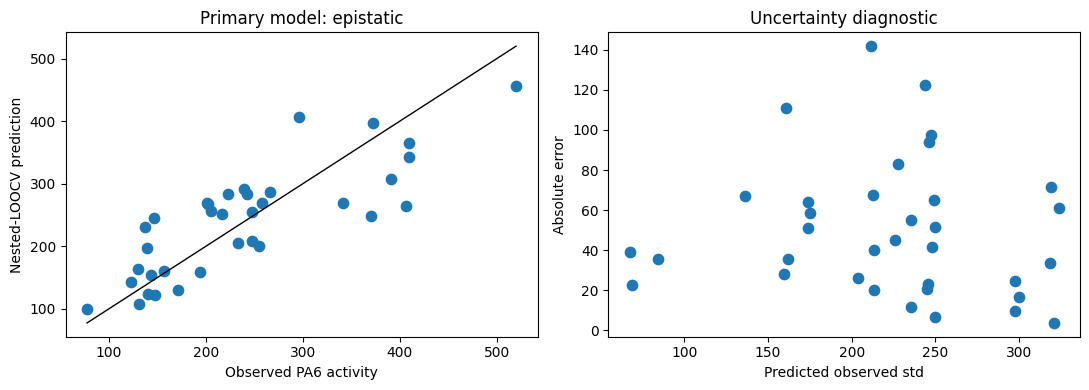

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(primary_predictions["observed"], primary_predictions["predicted"], s=55)
lo = min(primary_predictions["observed"].min(), primary_predictions["predicted"].min())
hi = max(primary_predictions["observed"].max(), primary_predictions["predicted"].max())
axes[0].plot([lo, hi], [lo, hi], color="black", linewidth=1)
axes[0].set_xlabel("Observed PA6 activity")
axes[0].set_ylabel("Nested-LOOCV prediction")
axes[0].set_title(f"Primary model: {best_primary_model}")

axes[1].scatter(primary_predictions["predicted_std_observed"], primary_predictions["abs_error"], s=55)
axes[1].set_xlabel("Predicted observed std")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("Uncertainty diagnostic")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "primary_model_prediction_and_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

## Exploratory family holdout

LOOCV mostly tests interpolation. This diagnostic asks what happens when
all variants containing a given target position are held out together.
It is explicitly exploratory because training sets become small and
chemically incomplete.

In [14]:
def select_full_data_params_for_model(df_eval, source, model_type):
    params, grid_result = select_hyperparameters_inner_loocv(df_eval, source=source, model_type=model_type)
    return params, grid_result


primary_params, primary_full_grid = select_full_data_params_for_model(df_core, descriptor_source, best_primary_model)
print("Exploratory full-data-selected params for family holdout:", primary_params)


def position_family_holdout(df_eval, source, params):
    rows = []
    for pos in POSITIONS:
        is_test = df_eval["mutation_positions"].apply(lambda s: pos in s)
        df_test = df_eval[is_test].copy()
        df_train = df_eval[~is_test].copy()
        if df_test.empty or len(df_train) < 5:
            continue
        pred = fit_and_predict_one_fold(df_train, df_test, source=source, **params)
        tmp = df_test[["variant_id", "mutations", "mutation_signature", "mutation_order", "activity_pa6"]].copy()
        tmp["heldout_position"] = pos
        tmp["observed"] = tmp["activity_pa6"]
        tmp["predicted"] = pred["mean"]
        tmp["predicted_std_observed"] = pred["std_observed"]
        tmp["abs_error"] = np.abs(tmp["observed"] - tmp["predicted"])
        rows.append(tmp.drop(columns=["activity_pa6"]))
    if not rows:
        return pd.DataFrame(), pd.DataFrame()
    result = pd.concat(rows, ignore_index=True)
    summary = (
        result.groupby("heldout_position")
        .agg(n=("abs_error", "size"), mae=("abs_error", "mean"), median_abs_error=("abs_error", "median"))
        .reset_index()
    )
    return result, summary


family_holdout_df, family_holdout_summary = position_family_holdout(df_core, descriptor_source, primary_params)
display(family_holdout_summary)
display(family_holdout_df.sort_values("abs_error", ascending=False).head(20))
family_holdout_df.to_csv(OUTPUT_DIR / "exploratory_position_family_holdout_predictions.csv", index=False)
family_holdout_summary.to_csv(OUTPUT_DIR / "exploratory_position_family_holdout_summary.csv", index=False)

Exploratory full-data-selected params for family holdout: {'lengthscale': 0.2, 'sigma_main': 0.5, 'sigma_epi': 4.0, 'sigma_noise': 0.5}


,heldout_position,n,mae,median_abs_error
0,99,15,52.619158,34.731433
1,134,21,149.665086,143.379435
2,304,26,72.724401,48.207917
3,330,11,83.858830,43.693677


,variant_id,mutations,mutation_signature,mutation_order,heldout_position,observed,predicted,predicted_std_observed,abs_error
28,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,134,520.000000,215.587239,135.948270,304.412761
54,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,304,520.000000,256.675069,355.572006,263.324931
31,D99G_F134W_D304M_R330A,D99G;F134W;D304M;R330A,99+134+304+330,4,134,410.000000,148.786865,144.611255,261.213135
32,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,99+134+304+330,4,134,391.000000,148.815061,144.611238,242.184939
17,F134W_D304L,F134W;D304L,134+304,2,134,370.333333,133.033289,122.777866,237.300045
43,F134W_D304M,F134W;D304M,134+304,2,304,409.666667,204.371867,326.605129,205.294800
18,F134W_D304I,F134W;D304I,134+304,2,134,341.333333,136.169989,139.214639,205.163345
16,F134W_D304M,F134W;D304M,134+304,2,134,409.666667,207.198234,122.037692,202.468433
24,D99R_F134W_R330A,D99R;F134W;R330A,99+134+330,3,134,406.000000,204.327378,136.215710,201.672622
69,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,99+134+304+330,4,330,391.000000,189.656391,275.199435,201.343609


## Exploratory descriptor-set sensitivity

This checks whether the qualitative epistasis conclusion is highly
dependent on one descriptor family. It is supplemental because descriptor
choice itself is another model-selection layer.

In [15]:
descriptor_sensitivity_rows = []


def compact_grid_for_sensitivity(model_type):
    lengthscale_values = (0.2, 0.5, 1.0)
    sigma_main_values = (0.5, 1.0)
    sigma_noise_values = (0.5, 1.0)
    sigma_epi_values = (0.0,) if model_type == "additive" else (1.0, 2.0, 4.0)
    return [
        {"lengthscale": ls, "sigma_main": sm, "sigma_epi": se, "sigma_noise": sn}
        for ls, sm, se, sn in product(lengthscale_values, sigma_main_values, sigma_epi_values, sigma_noise_values)
    ]


for source_name in DESCRIPTOR_SOURCES:
    source = residue_descriptor_table(source_name, standardize=True)
    for model_type in ("additive", "epistatic"):
        grid = compact_grid_for_sensitivity(model_type)
        grid_result = evaluate_grid_loocv(df_core, source=source, grid=grid, label=model_type)
        best = grid_result.iloc[0].to_dict()
        descriptor_sensitivity_rows.append({
            "descriptor_set": source_name,
            "descriptor_description": source.description,
            "model": model_type,
            **best,
        })

sensitivity_df = pd.DataFrame(descriptor_sensitivity_rows).sort_values(["mae", "rmse"]).reset_index(drop=True)
display(sensitivity_df)
sensitivity_df.to_csv(OUTPUT_DIR / "exploratory_descriptor_sensitivity.csv", index=False)

,descriptor_set,descriptor_description,model,lengthscale,sigma_main,sigma_epi,sigma_noise,mae,rmse,r2,pearson,spearman,nlpd_observed
0,physical,Two physical descriptors; PD1 relates to volum...,epistatic,0.2,0.5,4.0,0.5,37.506517,48.713356,0.778682,0.883089,0.863086,6.238166
1,z_scales,Z-scales; compact amino-acid physicochemical d...,epistatic,0.5,0.5,4.0,0.5,42.519271,54.373220,0.724265,0.851467,0.841796,6.293260
2,vhse,"VHSE scales; hydrophobic, steric and electroni...",epistatic,0.5,0.5,4.0,0.5,44.075087,56.714912,0.700004,0.837230,0.817004,6.305400
3,kidera,Kidera factors; 10-dimensional physicochemical...,epistatic,0.2,0.5,4.0,0.5,44.097570,56.782335,0.699290,0.836812,0.821206,6.306010
4,pcp,Physical-chemical property descriptors from pe...,epistatic,0.2,0.5,4.0,0.5,44.097572,56.782338,0.699290,0.836812,0.821206,6.306010
5,atchley,Atchley factors; multidimensional amino-acid d...,epistatic,0.2,0.5,4.0,0.5,44.097667,56.782435,0.699289,0.836811,0.821206,6.306010
6,physical,Two physical descriptors; PD1 relates to volum...,additive,1.0,0.5,0.0,0.5,55.908704,68.494381,0.562447,0.759312,0.792773,5.722533
7,z_scales,Z-scales; compact amino-acid physicochemical d...,additive,0.2,0.5,0.0,0.5,58.550568,70.417780,0.537528,0.738595,0.777645,5.755953
8,kidera,Kidera factors; 10-dimensional physicochemical...,additive,0.2,0.5,0.0,0.5,58.556226,70.425100,0.537431,0.738521,0.777645,5.756073
9,vhse,"VHSE scales; hydrophobic, steric and electroni...",additive,0.2,0.5,0.0,0.5,58.556227,70.425100,0.537431,0.738521,0.777645,5.756073


## Final reporting guidance

Use the nested LOOCV table as the primary result. A conservative wording:

> A package-derived physicochemical ANOVA-GP suggests that pairwise
> pocket-position interaction terms improve retrospective PA6 activity
> prediction relative to an additive model. Because the dataset contains
> only 35 four-position variants and lacks an external prospective test
> set, the model should be interpreted as hypothesis-generating rather
> than as a calibrated predictor.

In [16]:
report_bundle = {
    "nested_metrics": nested_metrics_df,
    "paired_errors": paired_errors.reset_index(),
    "calibration": calibration,
    "error_by_order": error_by_order,
    "descriptor_sensitivity": sensitivity_df,
}

for name, table in report_bundle.items():
    out_file = OUTPUT_DIR / f"{name}.csv"
    table.to_csv(out_file, index=False)
    print(name, "->", out_file)

nested_metrics -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/nested_metrics.csv
paired_errors -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/paired_errors.csv
calibration -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/calibration.csv
error_by_order -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/error_by_order.csv
descriptor_sensitivity -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/descriptor_sensitivity.csv


## Reviewer-hardening additions

The following cells implement additional controls requested after the
first reviewer-style evaluation:

- nested descriptor-family selection;
- strict position-family holdout with all model choices made on the
  training set only;
- simple baselines;
- an explicitly exploratory 3-way epistasis check;
- replicate-level bootstrap sensitivity.

Interpretation rule:

- nested descriptor/model selection and strict family holdout can be
  reported as validation diagnostics;
- 3-way epistasis and bootstrap sensitivity are exploratory support
  analyses and should not replace external validation.

### Nested descriptor and model selection

This cell nests descriptor-family selection together with model-family
and hyperparameter selection. It is more conservative than first picking
the best descriptor family from a global sensitivity table.

In [17]:
DESCRIPTOR_CACHE = {}


def get_descriptor_source(source_name):
    if source_name not in DESCRIPTOR_CACHE:
        DESCRIPTOR_CACHE[source_name] = residue_descriptor_table(source_name, standardize=True)
    return DESCRIPTOR_CACHE[source_name]


def make_joint_descriptor_model_grid():
    rows = []
    lengthscale_values = (0.2, 0.5)
    sigma_main_values = (0.5,)
    sigma_noise_values = (0.5,)

    for descriptor_set in DESCRIPTOR_SOURCES:
        for lengthscale, sigma_main, sigma_noise in product(
            lengthscale_values,
            sigma_main_values,
            sigma_noise_values,
        ):
            rows.append({
                "descriptor_set": descriptor_set,
                "model": "additive",
                "lengthscale": lengthscale,
                "sigma_main": sigma_main,
                "sigma_epi": 0.0,
                "sigma_noise": sigma_noise,
            })

            for sigma_epi in (2.0, 4.0):
                rows.append({
                    "descriptor_set": descriptor_set,
                    "model": "epistatic",
                    "lengthscale": lengthscale,
                    "sigma_main": sigma_main,
                    "sigma_epi": sigma_epi,
                    "sigma_noise": sigma_noise,
                })

    return rows


def evaluate_joint_setting_loocv(df_subset, setting):
    source = get_descriptor_source(setting["descriptor_set"])
    _, metrics = loocv_anova_gp(
        df_subset,
        source=source,
        lengthscale=setting["lengthscale"],
        sigma_main=setting["sigma_main"],
        sigma_epi=setting["sigma_epi"],
        sigma_noise=setting["sigma_noise"],
        label=f"{setting['descriptor_set']}:{setting['model']}",
    )
    return metrics


def select_joint_descriptor_model_inner_loocv(df_train, joint_grid):
    rows = []
    for setting in joint_grid:
        metrics = evaluate_joint_setting_loocv(df_train, setting)
        rows.append({**setting, **metrics})
    grid_df = pd.DataFrame(rows).sort_values(["mae", "rmse"]).reset_index(drop=True)
    best = grid_df.iloc[0].to_dict()
    best_setting = {
        key: best[key]
        for key in ["descriptor_set", "model", "lengthscale", "sigma_main", "sigma_epi", "sigma_noise"]
    }
    return best_setting, grid_df


def nested_loocv_descriptor_model_selection(df_eval, joint_grid):
    df_eval = df_eval.reset_index(drop=True)
    rows = []
    inner_grids = {}

    for outer_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[outer_idx]].copy()
        df_train = df_eval.drop(index=outer_idx).copy()
        variant_id = df_test["variant_id"].iloc[0]

        best_setting, inner_grid = select_joint_descriptor_model_inner_loocv(df_train, joint_grid)
        inner_grids[variant_id] = inner_grid

        source = get_descriptor_source(best_setting["descriptor_set"])
        pred = fit_and_predict_one_fold(
            df_train,
            df_test,
            source=source,
            lengthscale=best_setting["lengthscale"],
            sigma_main=best_setting["sigma_main"],
            sigma_epi=best_setting["sigma_epi"],
            sigma_noise=best_setting["sigma_noise"],
        )

        observed = float(df_test["activity_pa6"].iloc[0])
        predicted = float(pred["mean"][0])
        rows.append({
            "variant_id": variant_id,
            "mutations": df_test["mutations"].iloc[0],
            "mutation_signature": df_test["mutation_signature"].iloc[0],
            "mutation_order": int(df_test["mutation_order"].iloc[0]),
            "observed": observed,
            "predicted": predicted,
            "predicted_std_observed": float(pred["std_observed"][0]),
            "abs_error": abs(observed - predicted),
            **{f"selected_{key}": value for key, value in best_setting.items()},
            "inner_mae": float(inner_grid.iloc[0]["mae"]),
        })
        print(f"{outer_idx + 1:02d}/{len(df_eval)} {variant_id}: {best_setting['descriptor_set']} {best_setting['model']}")

    result = pd.DataFrame(rows)
    metrics = pd.DataFrame([{
        "analysis": "nested_descriptor_model_selection",
        **regression_metrics(result["observed"], result["predicted"], result["predicted_std_observed"]),
    }])
    selected_summary = (
        result[
            ["selected_descriptor_set", "selected_model", "selected_lengthscale", "selected_sigma_main", "selected_sigma_epi", "selected_sigma_noise"]
        ]
        .value_counts()
        .reset_index(name="count")
    )
    return result, metrics, selected_summary, inner_grids


joint_grid = make_joint_descriptor_model_grid()
nested_joint_predictions, nested_joint_metrics, nested_joint_selected_summary, nested_joint_inner_grids = (
    nested_loocv_descriptor_model_selection(df_core, joint_grid)
)

display(nested_joint_metrics)
display(nested_joint_selected_summary)
display(nested_joint_predictions.sort_values("abs_error", ascending=False).head(15))

nested_joint_predictions.to_csv(OUTPUT_DIR / "nested_descriptor_model_predictions.csv", index=False)
nested_joint_metrics.to_csv(OUTPUT_DIR / "nested_descriptor_model_metrics.csv", index=False)
nested_joint_selected_summary.to_csv(OUTPUT_DIR / "nested_descriptor_selected_settings.csv", index=False)

01/35 WT: physical epistatic
02/35 D99G: physical epistatic
03/35 D99V: physical epistatic
04/35 D99R: physical epistatic
05/35 F134W: physical epistatic
06/35 D304M: physical epistatic
07/35 D304E: physical epistatic
08/35 D304Q: physical epistatic
09/35 D304V: physical epistatic
10/35 D304W: physical epistatic
11/35 D304R: physical epistatic
12/35 D304L: physical epistatic
13/35 R330A: physical epistatic
14/35 R330Q: physical epistatic
15/35 F134W_D304M: physical epistatic
16/35 F134W_D304L: physical epistatic
17/35 F134W_D304I: physical epistatic
18/35 F134W_D304R: physical epistatic
19/35 F134W_D304E: physical epistatic
20/35 F134W_D304S: physical epistatic
21/35 F134W_D304V: physical epistatic
22/35 D99R_D304M: physical epistatic
23/35 D99R_F134W: physical epistatic
24/35 D99R_F134W_R330A: physical epistatic
25/35 D99R_F134W_D304M: physical epistatic
26/35 D99G_F134W_D304M: physical epistatic
27/35 D99V_F134W_D304M: physical epistatic
28/35 F134W_D304M_R330A: physical epistatic
29

,analysis,mae,rmse,r2,pearson,spearman,nlpd_observed
0,nested_descriptor_model_selection,40.91379,51.230293,0.755221,0.870006,0.861825,6.185249


,selected_descriptor_set,selected_model,selected_lengthscale,selected_sigma_main,selected_sigma_epi,selected_sigma_noise,count
0,physical,epistatic,0.2,0.5,4.0,0.5,26
1,physical,epistatic,0.2,0.5,2.0,0.5,8
2,physical,epistatic,0.5,0.5,4.0,0.5,1


,variant_id,mutations,mutation_signature,mutation_order,observed,predicted,predicted_std_observed,abs_error,selected_descriptor_set,selected_model,selected_lengthscale,selected_sigma_main,selected_sigma_epi,selected_sigma_noise,inner_mae
23,D99R_F134W_R330A,D99R;F134W;R330A,99+134+330,3,406.000000,266.705239,227.216623,139.294761,physical,epistatic,0.2,0.5,4.0,0.5,30.765003
29,D99R_F134W_D304M_R330A,D99R;F134W;D304M;R330A,99+134+304+330,4,296.000000,406.432497,174.040400,110.432497,physical,epistatic,0.2,0.5,4.0,0.5,26.251117
12,R330A,R330A,330,1,147.000000,234.693400,259.992218,87.693400,physical,epistatic,0.2,0.5,4.0,0.5,36.246474
31,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,99+134+304+330,4,391.000000,307.444745,227.928227,83.555255,physical,epistatic,0.2,0.5,4.0,0.5,35.970486
8,D304V,D304V,304,1,131.500000,49.319026,205.308875,82.180974,physical,epistatic,0.5,0.5,4.0,0.5,37.880362
11,D304L,D304L,304,1,137.500000,216.956030,195.081360,79.456030,physical,epistatic,0.2,0.5,4.0,0.5,36.224803
26,D99V_F134W_D304M,D99V;F134W;D304M,99+134+304,3,201.000000,272.062321,212.825685,71.062321,physical,epistatic,0.2,0.5,4.0,0.5,37.415025
27,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,520.000000,457.058266,105.698305,62.941734,physical,epistatic,0.2,0.5,2.0,0.5,38.373832
32,D99R_F134W_D304M_R330Q,D99R;F134W;D304M;R330Q,99+134+304+330,4,255.000000,200.055394,235.301317,54.944606,physical,epistatic,0.2,0.5,4.0,0.5,35.330801
20,F134W_D304V,F134W;D304V,134+304,2,202.333333,252.121852,252.077065,49.788518,physical,epistatic,0.2,0.5,4.0,0.5,37.476295


### Strict position-family holdout

The earlier family holdout used full-data-selected hyperparameters. This
stricter version selects descriptor family, model family and
hyperparameters using only the training set of each position-family
holdout.

In [18]:
def strict_position_family_holdout(df_eval, joint_grid):
    rows = []
    selection_rows = []

    for pos in POSITIONS:
        is_test = df_eval["mutation_positions"].apply(lambda positions: pos in positions)
        df_test = df_eval[is_test].copy()
        df_train = df_eval[~is_test].copy()

        if df_test.empty or len(df_train) < 5:
            continue

        best_setting, inner_grid = select_joint_descriptor_model_inner_loocv(df_train, joint_grid)
        source = get_descriptor_source(best_setting["descriptor_set"])
        pred = fit_and_predict_one_fold(
            df_train,
            df_test,
            source=source,
            lengthscale=best_setting["lengthscale"],
            sigma_main=best_setting["sigma_main"],
            sigma_epi=best_setting["sigma_epi"],
            sigma_noise=best_setting["sigma_noise"],
        )

        tmp = df_test[["variant_id", "mutations", "mutation_signature", "mutation_order", "activity_pa6"]].copy()
        tmp["heldout_position"] = pos
        tmp["observed"] = tmp["activity_pa6"]
        tmp["predicted"] = pred["mean"]
        tmp["predicted_std_observed"] = pred["std_observed"]
        tmp["abs_error"] = np.abs(tmp["observed"] - tmp["predicted"])
        for key, value in best_setting.items():
            tmp[f"selected_{key}"] = value
        rows.append(tmp.drop(columns=["activity_pa6"]))

        selection_rows.append({
            "heldout_position": pos,
            "n_train": len(df_train),
            "n_test": len(df_test),
            **{f"selected_{key}": value for key, value in best_setting.items()},
            "inner_mae": float(inner_grid.iloc[0]["mae"]),
        })

        print(f"held out {pos}: {best_setting}")

    result = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    summary = (
        result.groupby("heldout_position")
        .agg(
            n=("abs_error", "size"),
            mae=("abs_error", "mean"),
            rmse=("abs_error", lambda x: float(np.sqrt(np.mean(np.asarray(x) ** 2)))),
            median_abs_error=("abs_error", "median"),
        )
        .reset_index()
        if not result.empty else pd.DataFrame()
    )
    selections = pd.DataFrame(selection_rows)
    return result, summary, selections


strict_family_holdout_df, strict_family_holdout_summary, strict_family_holdout_selections = (
    strict_position_family_holdout(df_core, joint_grid)
)

display(strict_family_holdout_summary)
display(strict_family_holdout_selections)
display(strict_family_holdout_df.sort_values("abs_error", ascending=False).head(20))

strict_family_holdout_df.to_csv(OUTPUT_DIR / "strict_position_family_holdout_predictions.csv", index=False)
strict_family_holdout_summary.to_csv(OUTPUT_DIR / "strict_position_family_holdout_summary.csv", index=False)
strict_family_holdout_selections.to_csv(OUTPUT_DIR / "strict_position_family_holdout_selected_settings.csv", index=False)

held out 99: {'descriptor_set': 'physical', 'model': 'epistatic', 'lengthscale': 0.2, 'sigma_main': 0.5, 'sigma_epi': 2.0, 'sigma_noise': 0.5}
held out 134: {'descriptor_set': 'physical', 'model': 'additive', 'lengthscale': 0.2, 'sigma_main': 0.5, 'sigma_epi': 0.0, 'sigma_noise': 0.5}
held out 304: {'descriptor_set': 'physical', 'model': 'additive', 'lengthscale': 0.5, 'sigma_main': 0.5, 'sigma_epi': 0.0, 'sigma_noise': 0.5}
held out 330: {'descriptor_set': 'physical', 'model': 'epistatic', 'lengthscale': 0.2, 'sigma_main': 0.5, 'sigma_epi': 4.0, 'sigma_noise': 0.5}


,heldout_position,n,mae,rmse,median_abs_error
0,99,15,56.810779,70.445081,33.714511
1,134,21,147.094765,170.686255,106.580197
2,304,26,70.512785,105.830175,38.107767
3,330,11,77.869429,105.106208,36.631706


,heldout_position,n_train,n_test,selected_descriptor_set,selected_model,selected_lengthscale,selected_sigma_main,selected_sigma_epi,selected_sigma_noise,inner_mae
0,99,20,15,physical,epistatic,0.2,0.5,2.0,0.5,33.646015
1,134,14,21,physical,additive,0.2,0.5,0.0,0.5,28.542343
2,304,9,26,physical,additive,0.5,0.5,0.0,0.5,45.932686
3,330,24,11,physical,epistatic,0.2,0.5,4.0,0.5,28.078864


,variant_id,mutations,mutation_signature,mutation_order,heldout_position,observed,predicted,predicted_std_observed,abs_error,selected_descriptor_set,selected_model,selected_lengthscale,selected_sigma_main,selected_sigma_epi,selected_sigma_noise
28,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,134,520.000000,157.464952,23.505599,362.535048,physical,additive,0.2,0.5,0.0,0.5
54,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,304,520.000000,228.483358,61.303538,291.516642,physical,additive,0.5,0.5,0.0,0.5
24,D99R_F134W_R330A,D99R;F134W;R330A,99+134+330,3,134,406.000000,147.386411,23.511179,258.613589,physical,additive,0.2,0.5,0.0,0.5
16,F134W_D304M,F134W;D304M,134+304,2,134,409.666667,156.525633,22.584338,253.141034,physical,additive,0.2,0.5,0.0,0.5
31,D99G_F134W_D304M_R330A,D99G;F134W;D304M;R330A,99+134+304+330,4,134,410.000000,160.359122,24.341667,249.640878,physical,additive,0.2,0.5,0.0,0.5
32,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,99+134+304+330,4,134,391.000000,161.063312,24.308703,229.936688,physical,additive,0.2,0.5,0.0,0.5
17,F134W_D304L,F134W;D304L,134+304,2,134,370.333333,149.844151,22.653235,220.489182,physical,additive,0.2,0.5,0.0,0.5
43,F134W_D304M,F134W;D304M,134+304,2,304,409.666667,190.871295,60.820406,218.795371,physical,additive,0.5,0.5,0.0,0.5
29,F134W_D304M_R330Q,F134W;D304M;R330Q,134+304+330,3,134,372.000000,156.306123,23.516598,215.693877,physical,additive,0.2,0.5,0.0,0.5
69,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,99+134+304+330,4,330,391.000000,196.396068,275.457901,194.603932,physical,epistatic,0.2,0.5,4.0,0.5


### Baseline models

These baselines test whether the ANOVA-GP is better than simple
alternatives. Ridge and k-nearest-neighbor hyperparameters are selected
by inner LOOCV inside each outer fold.

In [19]:
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


def onehot_pocket_features(df_eval):
    rows = []
    for pocket in df_eval["pocket"]:
        row = {}
        for pos in POSITIONS:
            for aa in CANONICAL_AA:
                row[f"pos{pos}_{aa}"] = int(pocket[pos] == aa)
        rows.append(row)
    return pd.DataFrame(rows, index=df_eval.index).to_numpy(dtype=float)


def flattened_descriptor_features(df_eval, source):
    rows = []
    for pocket in df_eval["pocket"]:
        rows.append(np.concatenate([aa_descriptor_vector(pocket[pos], source) for pos in POSITIONS]))
    return np.vstack(rows)


def inner_loocv_regressor_mae(X_train, y_train, fit_predict_factory):
    preds = []
    obs = []
    for i in range(len(y_train)):
        train_idx = [j for j in range(len(y_train)) if j != i]
        pred = fit_predict_factory(X_train[train_idx], y_train[train_idx], X_train[[i]])
        preds.append(float(pred[0]))
        obs.append(float(y_train[i]))
    return mean_absolute_error(obs, preds)


def select_ridge_alpha(X_train, y_train, alphas=(0.01, 0.1, 1.0, 10.0, 100.0)):
    rows = []
    for alpha in alphas:
        mae = inner_loocv_regressor_mae(
            X_train,
            y_train,
            lambda Xtr, ytr, Xte: Ridge(alpha=alpha).fit(Xtr, ytr).predict(Xte),
        )
        rows.append({"alpha": alpha, "inner_mae": mae})
    return pd.DataFrame(rows).sort_values("inner_mae").iloc[0].to_dict()


def select_knn_k(X_train, y_train, k_values=(1, 3, 5, 7)):
    rows = []
    for k in k_values:
        if k >= len(y_train):
            continue
        mae = inner_loocv_regressor_mae(
            X_train,
            y_train,
            lambda Xtr, ytr, Xte: KNeighborsRegressor(n_neighbors=k, weights="distance").fit(Xtr, ytr).predict(Xte),
        )
        rows.append({"k": k, "inner_mae": mae})
    return pd.DataFrame(rows).sort_values("inner_mae").iloc[0].to_dict()


def loocv_baselines(df_eval, descriptor_source_for_knn):
    df_eval = df_eval.reset_index(drop=True)
    y = df_eval["activity_pa6"].to_numpy(dtype=float)
    X_onehot = onehot_pocket_features(df_eval)
    X_desc = flattened_descriptor_features(df_eval, descriptor_source_for_knn)
    rows = []

    for test_idx in range(len(df_eval)):
        train_idx = [i for i in range(len(df_eval)) if i != test_idx]
        variant_id = df_eval.loc[test_idx, "variant_id"]
        observed = float(y[test_idx])

        y_train = y[train_idx]
        rows.append({
            "model": "train_mean",
            "variant_id": variant_id,
            "observed": observed,
            "predicted": float(np.mean(y_train)),
            "abs_error": abs(observed - float(np.mean(y_train))),
        })

        ridge_best = select_ridge_alpha(X_onehot[train_idx], y_train)
        ridge = Ridge(alpha=ridge_best["alpha"]).fit(X_onehot[train_idx], y_train)
        ridge_pred = float(ridge.predict(X_onehot[[test_idx]])[0])
        rows.append({
            "model": "ridge_onehot",
            "variant_id": variant_id,
            "observed": observed,
            "predicted": ridge_pred,
            "abs_error": abs(observed - ridge_pred),
            "selected_alpha": ridge_best["alpha"],
        })

        knn_best = select_knn_k(X_desc[train_idx], y_train)
        knn = KNeighborsRegressor(n_neighbors=int(knn_best["k"]), weights="distance").fit(X_desc[train_idx], y_train)
        knn_pred = float(knn.predict(X_desc[[test_idx]])[0])
        rows.append({
            "model": "knn_descriptor",
            "variant_id": variant_id,
            "observed": observed,
            "predicted": knn_pred,
            "abs_error": abs(observed - knn_pred),
            "selected_k": int(knn_best["k"]),
        })

        rf = RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=42,
        ).fit(X_onehot[train_idx], y_train)
        rf_pred = float(rf.predict(X_onehot[[test_idx]])[0])
        rows.append({
            "model": "random_forest_onehot_fixed",
            "variant_id": variant_id,
            "observed": observed,
            "predicted": rf_pred,
            "abs_error": abs(observed - rf_pred),
        })

    result = pd.DataFrame(rows)
    metrics = []
    for model, group in result.groupby("model"):
        metrics.append({"model": model, **regression_metrics(group["observed"], group["predicted"])})
    return result, pd.DataFrame(metrics).sort_values("mae")


baseline_predictions, baseline_metrics = loocv_baselines(df_core, descriptor_source)
display(baseline_metrics)
display(baseline_predictions.sort_values("abs_error", ascending=False).head(20))

baseline_predictions.to_csv(OUTPUT_DIR / "baseline_loocv_predictions.csv", index=False)
baseline_metrics.to_csv(OUTPUT_DIR / "baseline_loocv_metrics.csv", index=False)

,model,mae,rmse,r2,pearson,spearman
1,random_forest_onehot_fixed,47.796377,62.636593,0.634087,0.796388,0.717837
0,knn_descriptor,58.836348,72.583566,0.508642,0.713648,0.734365
2,ridge_onehot,69.567655,82.119313,0.371056,0.610906,0.690665
3,train_mean,84.483894,106.592957,-0.059689,-1.000000,-0.999930


,model,variant_id,observed,predicted,abs_error,selected_alpha,selected_k
108,train_mean,F134W_D304M_R330A,520.000000,231.634804,288.365196,NaN,NaN
109,ridge_onehot,F134W_D304M_R330A,520.000000,309.167208,210.832792,10.0,NaN
110,knn_descriptor,F134W_D304M_R330A,520.000000,340.605590,179.394410,NaN,7.0
120,train_mean,D99G_F134W_D304M_R330A,410.000000,234.870098,175.129902,NaN,NaN
56,train_mean,F134W_D304M,409.666667,234.879902,174.786765,NaN,NaN
92,train_mean,D99R_F134W_R330A,406.000000,234.987745,171.012255,NaN,NaN
0,train_mean,WT,77.666667,244.644608,166.977941,NaN,NaN
58,knn_descriptor,F134W_D304M,409.666667,250.821244,158.845423,NaN,5.0
124,train_mean,D99V_F134W_D304M_R330A,391.000000,235.428922,155.571078,NaN,NaN
111,random_forest_onehot_fixed,F134W_D304M_R330A,520.000000,375.884686,144.115314,NaN,NaN


### Exploratory 3-way epistasis

The primary model contains pairwise epistasis. This diagnostic tests
whether adding a 3-way term helps under a small, restricted grid. Because
this is not nested over all modeling choices, it is exploratory.

In [20]:
def build_three_way_kernel(position_kernels):
    positions = list(position_kernels)
    products = []
    for i, pos_a in enumerate(positions):
        for j, pos_b in enumerate(positions[i + 1:], start=i + 1):
            for pos_c in positions[j + 1:]:
                products.append(position_kernels[pos_a] * position_kernels[pos_b] * position_kernels[pos_c])
    if not products:
        raise ValueError("At least three positions are required for 3-way epistasis.")
    return np.mean(np.stack(products, axis=0), axis=0)


def build_total_anova_kernel_with_three_way(position_kernels, sigma_main=1.0, sigma_epi=0.0, sigma_three=0.0):
    k_main = build_main_kernel(position_kernels)
    k_epi = build_epistasis_kernel(position_kernels)
    k_three = build_three_way_kernel(position_kernels)
    k_total = (
        float(sigma_main) ** 2 * k_main
        + float(sigma_epi) ** 2 * k_epi
        + float(sigma_three) ** 2 * k_three
    )
    return k_total, k_main, k_epi, k_three


def build_total_cross_kernel_with_three_way(train_pockets, test_pockets, source, lengthscales=1.0, sigma_main=1.0, sigma_epi=0.0, sigma_three=0.0):
    cross = build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=lengthscales)
    k_main = build_main_kernel(cross)
    k_epi = build_epistasis_kernel(cross)
    k_three = build_three_way_kernel(cross)
    return (
        float(sigma_main) ** 2 * k_main
        + float(sigma_epi) ** 2 * k_epi
        + float(sigma_three) ** 2 * k_three
    )


def fit_and_predict_one_fold_three_way(df_train, df_test, source, lengthscale, sigma_main, sigma_epi, sigma_three, sigma_noise):
    train_pockets = df_train["pocket"].tolist()
    test_pockets = df_test["pocket"].tolist()
    train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source)
    train_kernels = build_position_kernels(train_arrays, lengthscales=lengthscale)
    K_train, _, _, _ = build_total_anova_kernel_with_three_way(
        train_kernels,
        sigma_main=sigma_main,
        sigma_epi=sigma_epi,
        sigma_three=sigma_three,
    )
    gp_fit = fit_gp_from_kernel(
        K_train,
        y=df_train["activity_pa6"].to_numpy(dtype=float),
        sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
        sigma_noise=sigma_noise,
    )
    K_test_train = build_total_cross_kernel_with_three_way(
        train_pockets,
        test_pockets,
        source=source,
        lengthscales=lengthscale,
        sigma_main=sigma_main,
        sigma_epi=sigma_epi,
        sigma_three=sigma_three,
    )
    K_test_diag = np.full(len(df_test), float(sigma_main) ** 2 + float(sigma_epi) ** 2 + float(sigma_three) ** 2)
    return gp_predict_from_fit(gp_fit, K_test_train, K_test_diag)


def loocv_three_way(df_eval, source, lengthscale, sigma_main, sigma_epi, sigma_three, sigma_noise):
    rows = []
    df_eval = df_eval.reset_index(drop=True)
    for test_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[test_idx]].copy()
        df_train = df_eval.drop(index=test_idx).copy()
        pred = fit_and_predict_one_fold_three_way(
            df_train,
            df_test,
            source=source,
            lengthscale=lengthscale,
            sigma_main=sigma_main,
            sigma_epi=sigma_epi,
            sigma_three=sigma_three,
            sigma_noise=sigma_noise,
        )
        observed = float(df_test["activity_pa6"].iloc[0])
        predicted = float(pred["mean"][0])
        rows.append({
            "variant_id": df_test["variant_id"].iloc[0],
            "observed": observed,
            "predicted": predicted,
            "predicted_std_observed": float(pred["std_observed"][0]),
            "abs_error": abs(observed - predicted),
            "sigma_three": sigma_three,
        })
    result = pd.DataFrame(rows)
    return result, regression_metrics(result["observed"], result["predicted"], result["predicted_std_observed"])


three_way_rows = []
three_way_predictions = []
for sigma_three in (0.0, 0.5, 1.0, 2.0):
    preds, metrics = loocv_three_way(
        df_core,
        source=descriptor_source,
        lengthscale=0.2,
        sigma_main=0.5,
        sigma_epi=4.0,
        sigma_three=sigma_three,
        sigma_noise=0.5,
    )
    three_way_rows.append({"sigma_three": sigma_three, **metrics})
    three_way_predictions.append(preds)

three_way_summary = pd.DataFrame(three_way_rows).sort_values("mae")
three_way_predictions_df = pd.concat(three_way_predictions, ignore_index=True)

display(three_way_summary)
display(three_way_predictions_df.sort_values("abs_error", ascending=False).head(20))

three_way_summary.to_csv(OUTPUT_DIR / "exploratory_three_way_epistasis_summary.csv", index=False)
three_way_predictions_df.to_csv(OUTPUT_DIR / "exploratory_three_way_epistasis_predictions.csv", index=False)

,sigma_three,mae,rmse,r2,pearson,spearman,nlpd_observed
0,0.0,44.097570,56.782335,0.699290,0.836812,0.821206,6.306010
1,0.5,44.661423,57.288537,0.693905,0.833558,0.821206,6.342635
2,1.0,45.686089,58.289855,0.683111,0.826887,0.811261,6.426844
3,2.0,47.642995,60.420961,0.659516,0.812164,0.797395,6.630638


,variant_id,observed,predicted,predicted_std_observed,abs_error,sigma_three
128,D99R_F134W_R330A,406.000000,245.243327,327.481085,160.756673,2.0
93,D99R_F134W_R330A,406.000000,254.511798,261.898968,151.488202,1.0
58,D99R_F134W_R330A,406.000000,260.236519,237.151492,145.763481,0.5
23,D99R_F134W_R330A,406.000000,263.298559,226.994517,142.701441,0.0
15,F134W_D304L,370.333333,247.757009,243.850849,122.576324,0.0
50,F134W_D304L,370.333333,247.949992,248.488849,122.383341,0.5
85,F134W_D304L,370.333333,248.280294,261.744172,122.053039,1.0
120,F134W_D304L,370.333333,248.513564,307.798422,121.819769,2.0
134,D99R_F134W_D304M_R330A,296.000000,416.594137,260.623692,120.594137,2.0
99,D99R_F134W_D304M_R330A,296.000000,413.576109,202.553594,117.576109,1.0


### Replicate-level bootstrap sensitivity

This bootstrap resamples activity replicates within each variant and
reruns a fixed primary GP configuration. It estimates how much the
performance metrics move because the experimental target means are based
on few replicates.

In [21]:
rng = np.random.default_rng(42)


def bootstrap_activity_targets(df_eval, rng):
    df_boot = df_eval.copy()
    activity_values = []
    sem_values = []
    for _, row in df_boot.iterrows():
        vals = pd.to_numeric(row[activity_rep_cols], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            activity_values.append(np.nan)
            sem_values.append(np.nan)
            continue
        sampled = rng.choice(vals, size=len(vals), replace=True)
        activity_values.append(float(np.mean(sampled)))
        if len(sampled) > 1:
            sem_values.append(float(np.std(sampled, ddof=1) / np.sqrt(len(sampled))))
        else:
            sem_values.append(float(fallback_sem))
    df_boot["activity_pa6"] = activity_values
    df_boot["activity_sem_for_gp"] = pd.Series(sem_values).fillna(fallback_sem).to_numpy()
    return df_boot


def bootstrap_primary_performance(df_eval, source, params, n_boot=100):
    rows = []
    for b in range(n_boot):
        df_boot = bootstrap_activity_targets(df_eval, rng)
        _, metrics = loocv_anova_gp(
            df_boot,
            source=source,
            lengthscale=params["lengthscale"],
            sigma_main=params["sigma_main"],
            sigma_epi=params["sigma_epi"],
            sigma_noise=params["sigma_noise"],
            label="bootstrap_primary",
        )
        rows.append({"bootstrap": b, **metrics})
    return pd.DataFrame(rows)


bootstrap_params = {
    "lengthscale": 0.2,
    "sigma_main": 0.5,
    "sigma_epi": 4.0,
    "sigma_noise": 0.5,
}

bootstrap_metrics = bootstrap_primary_performance(
    df_core,
    source=descriptor_source,
    params=bootstrap_params,
    n_boot=100,
)

bootstrap_summary = (
    bootstrap_metrics
    .agg(["mean", "std", "min", "median", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(bootstrap_summary)
display(bootstrap_metrics.head())

bootstrap_metrics.to_csv(OUTPUT_DIR / "bootstrap_replicate_primary_metrics.csv", index=False)
bootstrap_summary.to_csv(OUTPUT_DIR / "bootstrap_replicate_primary_summary.csv", index=False)

,metric,mean,std,min,median,max
0,bootstrap,49.500000,29.011492,0.000000,49.500000,99.000000
1,mae,44.796289,1.652266,41.355172,44.629535,48.832261
2,rmse,57.395274,1.522460,53.416055,57.330417,61.081903
3,r2,0.693111,0.015739,0.658011,0.693610,0.733189
4,pearson,0.833285,0.009162,0.812702,0.833614,0.856362
5,spearman,0.815945,0.013555,0.777085,0.816864,0.847538
6,nlpd_observed,6.307642,0.008264,6.287211,6.307874,6.326733


,bootstrap,mae,rmse,r2,pearson,spearman,nlpd_observed
0,0,44.746501,57.539168,0.691542,0.832254,0.811878,6.308354
1,1,46.572273,58.516880,0.679689,0.825829,0.814566,6.306876
2,2,44.591082,57.567812,0.695971,0.834958,0.811204,6.313826
3,3,44.644356,57.820645,0.689263,0.831433,0.801597,6.307143
4,4,46.678376,57.902447,0.681644,0.826371,0.819302,6.302848


### Updated automatic summary

This final table collects the reviewer-hardening diagnostics. If the
strict diagnostics disagree with the easier LOOCV result, the stricter
diagnostic should dominate the written interpretation.

In [22]:
hardening_summary = {
    "nested_descriptor_model_metrics": nested_joint_metrics,
    "nested_descriptor_selected_settings": nested_joint_selected_summary,
    "strict_family_holdout_summary": strict_family_holdout_summary,
    "baseline_metrics": baseline_metrics,
    "three_way_summary": three_way_summary,
    "bootstrap_summary": bootstrap_summary,
}

for name, table in hardening_summary.items():
    out_file = OUTPUT_DIR / f"{name}.csv"
    table.to_csv(out_file, index=False)
    print(name, "->", out_file)

nested_descriptor_model_metrics -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/nested_descriptor_model_metrics.csv
nested_descriptor_selected_settings -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/nested_descriptor_selected_settings.csv
strict_family_holdout_summary -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/strict_family_holdout_summary.csv
baseline_metrics -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/baseline_metrics.csv
three_way_summary -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/three_way_summary.csv
bootstrap_summary -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/bootstrap_summary.csv
